### Notebook to generate CPDB with same constraints applied to CIRPIN

In [1]:
import pandas as pd
fp ='/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/sequence_alignment/CPDB_full_data_sccs_fixed.csv'

In [2]:
df= pd.read_csv(fp)

In [3]:
df.head()


,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000,P17560,Q9RC92
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4


In [4]:

# Initialize list to track engineered CPs
engineered_CPs = []

In [5]:
print(f"Initial dataframe shape: {df.shape}")
print("-" * 50)

Initial dataframe shape: (4169, 13)
--------------------------------------------------


In [6]:
# Step 1: Filter for tmscore_cp_min > 0.5
df_filtered = df[df['tmscore_cp_min'] > 0.5].copy()
print(f"Step 1 - After filtering tmscore_cp_min > 0.5: {df_filtered.shape}")
print("-" * 50)

Step 1 - After filtering tmscore_cp_min > 0.5: (2535, 13)
--------------------------------------------------


In [7]:
# Step 2: Filter for tmscore_min_difference > 0
df_filtered = df_filtered[df_filtered['tm_score_min_difference'] > 0].copy()
print(f"Step 2 - After filtering tm_score_min_difference > 0: {df_filtered.shape}")
print("-" * 50)

Step 2 - After filtering tm_score_min_difference > 0: (2259, 13)
--------------------------------------------------


In [8]:
# Step 3: Remove pairs with matching uniprot IDs (add to engineered_CPs list)
# Identify rows with matching UniProt IDs
matching_uniprot = df_filtered['Protein1_uniprot'] == df_filtered['Protein2_uniprot']

# Add these entries to engineered_CPs list
engineered_CPs = df_filtered[matching_uniprot].to_dict('records')

# Remove these pairs from the dataframe
df_filtered = df_filtered[~matching_uniprot].copy()
print(f"Step 3 - After removing matching UniProt IDs: {df_filtered.shape}")
print(f"Number of engineered CPs found: {len(engineered_CPs)}")
print("-" * 50)

Step 3 - After removing matching UniProt IDs: (2199, 13)
Number of engineered CPs found: 60
--------------------------------------------------


In [10]:
# Remove pairs where either protein has a UniProt ID in the engineered list
# Step 3b: Remove any pairs that contain a UniProt ID from the engineered_CPs list
# Extract all UniProt IDs from engineered CPs
engineered_uniprot_ids = set()
for cp in engineered_CPs:
    engineered_uniprot_ids.add(cp['Protein1_uniprot'])
    engineered_uniprot_ids.add(cp['Protein2_uniprot'])




contains_engineered_uniprot = (
    df_filtered['Protein1_uniprot'].isin(engineered_uniprot_ids) |
    df_filtered['Protein2_uniprot'].isin(engineered_uniprot_ids)
)

df_filtered = df_filtered[~contains_engineered_uniprot].copy()
print(f"Step 3b - After removing pairs containing engineered UniProt IDs: {df_filtered.shape}")
print("-" * 50)

Step 3b - After removing pairs containing engineered UniProt IDs: (2071, 13)
--------------------------------------------------


In [11]:
# Step 4: Remove pairs that have a sccs that begins with b.29.1
# Check both Protein1_sccs and Protein2_sccs
sccs_filter = (
    df_filtered['Protein1_sccs'].str.startswith('b.29.1') | 
    df_filtered['Protein2_sccs'].str.startswith('b.29.1')
)

df_filtered = df_filtered[~sccs_filter].copy()
print(f"Step 4 - After removing pairs with sccs beginning with 'b.29.1': {df_filtered.shape}")
print("-" * 50)

print(f"\nFinal filtered dataframe shape: {df_filtered.shape}")
print(f"Total engineered CPs: {len(engineered_CPs)}")

# Display sample of results
print("\nFirst few rows of filtered dataframe:")
print(df_filtered.head())

# Display engineered CPs if any exist
if engineered_CPs:
    print("\nEngineered CPs:")
    for i, cp in enumerate(engineered_CPs, 1):
        print(f"{i}. {cp['Protein1']} - {cp['Protein2']} (UniProt: {cp['Protein1_uniprot']})")

Step 4 - After removing pairs with sccs beginning with 'b.29.1': (1467, 13)
--------------------------------------------------

Final filtered dataframe shape: (1467, 13)
Total engineered CPs: 60

First few rows of filtered dataframe:
  Protein1 Protein2  tmscore_max  tmscore_cp_max  tmscore_min  tmscore_cp_min  \
1    1fp3A    1wu4A      0.67768         0.67887      0.67768         0.67887   
2    1fp3A    2drqA      0.67558         0.67691      0.67558         0.67691   
3    1fp3A    1wu6A      0.67434         0.67558      0.67434         0.67558   
4    1fp3A    1hzfA      0.54695         0.55763      0.54695         0.55763   
5    1fp3A    1ks8A      0.63233         0.69125      0.59385         0.64707   

   progres_score  cirpin_score Protein1_sccs Protein2_sccs  \
1       0.971649      0.990784     a.102.1.3     a.102.1.2   
2       0.976586      0.990878     a.102.1.3     a.102.1.2   
3       0.974675      0.990933     a.102.1.3     a.102.1.2   
4       0.911674      0.948243

Histogram saved successfully!


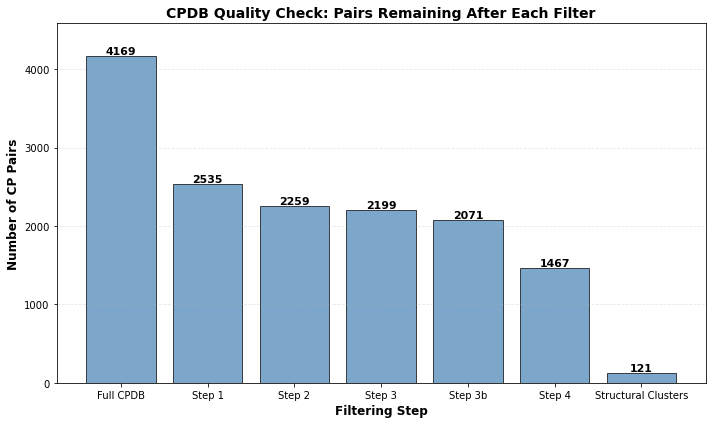

In [20]:
import matplotlib.pyplot as plt

# Data
steps = ['Full CPDB', 'Step 1', 'Step 2', 'Step 3', 'Step 3b', 'Step 4', 'Structural Clusters']
counts = [4169, 2535, 2259, 2199, 2071, 1467, 121]

# Create the histogram
plt.figure(figsize=(10, 6))
bars = plt.bar(steps, counts, color='steelblue', edgecolor='black', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the plot
plt.xlabel('Filtering Step', fontsize=12, fontweight='bold')
plt.ylabel('Number of CP Pairs', fontsize=12, fontweight='bold')
plt.title('CPDB Quality Check: Pairs Remaining After Each Filter', fontsize=14, fontweight='bold')
plt.ylim(0, max(counts) * 1.1)  # Add some space above the tallest bar
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Tight layout for better spacing
plt.tight_layout()

# Save the figure
plt.savefig('CPDB_filtering_histogram.png', dpi=300, bbox_inches='tight')
print("Histogram saved successfully!")

# Display the plot
plt.show()

In [12]:
df_filtered.head()

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference,Protein1_uniprot,Protein2_uniprot
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119,P17560,Q9KB30
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133,P17560,Q9KB30
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124,P17560,Q9KB30
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068,P17560,P0C0L4
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,a.102.1.2,0.05322,P17560,O77044


In [16]:
# Get all unique protein names from both Protein1 and Protein2 columns
unique_protein_names = pd.concat([
    df_filtered['Protein1'],
    df_filtered['Protein2']
]).unique()

print(f"\n\nTotal unique protein names in filtered dataframe: {len(unique_protein_names)}")
print("\nUnique protein names:")
print(sorted(unique_protein_names))



Total unique protein names in filtered dataframe: 795

Unique protein names:
['1a0rB', '1a22A', '1a25A', '1a4gA', '1a4lA', '1a50A', '1a5cA', '1a7mA', '1ad1A', '1aewA', '1aj0A', '1al3A', '1aluA', '1amfA', '1atgA', '1atzA', '1au1A', '1auoA', '1aw1A', '1ax8A', '1axiA', '1b30A', '1b4kA', '1b54A', '1b5lA', '1b5tA', '1b68A', '1b71A', '1b9sA', '1b9xA', '1bbhA', '1bcfA', '1bf6A', '1bg7A', '1bgcA', '1bgdA', '1bocA', '1booA', '1brlA', '1brlB', '1buyA', '1bynA', '1bz4A', '1c0eA', '1c3dA', '1c4qA', '1c4wA', '1c9iA', '1c9lA', '1c9oA', '1cd9A', '1cnt1', '1cqmA', '1crzA', '1csmA', '1cspA', '1ct5A', '1cvmA', '1cxzB', '1d1qA', '1d2aA', '1d9eA', '1dbtA', '1ddnA', '1df6A', '1dhnA', '1dkwA', '1dl3A', '1dorA', '1dpsA', '1dqgA', '1dqyA', '1dqzA', '1drjA', '1dtlA', '1dusA', '1dv7A', '1dy7A', '1dzbA', '1e0wA', '1e1aA', '1e9cA', '1e9fA', '1ea8A', '1eavA', '1eepA', '1eerA', '1eg2A', '1eixA', '1emrA', '1eumA', '1eurA', '1evsA', '1eyeA', '1ezwA', '1f07A', '1f1mA', '1f2jA', '1f30A', '1f38A', '1f3rB', '1f5zA', '1

In [17]:
import os
import shutil

# Define your source and destination directories
source_dir = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2'  # Change this to your PDB directory
dest_dir = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/CPDB_constraint_filtered'  # Change this to where you want to copy files

# Create destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# Convert protein names to PDB filename format
# e.g., '1a0rB' -> '1A0R_B.pdb'
copied_files = []
not_found_files = []

print(f"Looking for {len(unique_protein_names)} unique proteins...")
print("-" * 50)

for protein_name in unique_protein_names:
    # Extract PDB ID (first 4 characters) and chain (last character)
    pdb_id = protein_name[:4].upper()
    chain = protein_name[4:].upper()
    
    # Construct the expected filename
    pdb_filename = f"{pdb_id}_{chain}.pdb"
    
    source_path = os.path.join(source_dir, pdb_filename)
    dest_path = os.path.join(dest_dir, pdb_filename)
    
    # Check if file exists and copy it
    if os.path.exists(source_path):
        shutil.copy2(source_path, dest_path)
        copied_files.append(pdb_filename)
        print(f"✓ Copied: {pdb_filename}")
    else:
        not_found_files.append(pdb_filename)
        print(f"✗ Not found: {pdb_filename}")

print("-" * 50)
print(f"\nSummary:")
print(f"Total proteins to find: {len(unique_protein_names)}")
print(f"Successfully copied: {len(copied_files)}")
print(f"Not found: {len(not_found_files)}")

if not_found_files:
    print(f"\nFiles not found ({len(not_found_files)}):")
    for filename in not_found_files[:20]:  # Show first 20
        print(f"  - {filename}")
    if len(not_found_files) > 20:
        print(f"  ... and {len(not_found_files) - 20} more")

Looking for 795 unique proteins...
--------------------------------------------------
✓ Copied: 1FP3_A.pdb
✓ Copied: 1NC5_A.pdb
✓ Copied: 1V5C_A.pdb
✓ Copied: 1VD5_A.pdb
✓ Copied: 1WZZ_A.pdb
✓ Copied: 2AHF_A.pdb
✓ Copied: 2GH4_A.pdb
✓ Copied: 1A22_A.pdb
✓ Copied: 1A7M_A.pdb
✓ Copied: 1AEW_A.pdb
✓ Copied: 1ALU_A.pdb
✓ Copied: 1AU1_A.pdb
✓ Copied: 1AX8_A.pdb
✓ Copied: 1AXI_A.pdb
✓ Copied: 1B5L_A.pdb
✓ Copied: 1BBH_A.pdb
✓ Copied: 1BCF_A.pdb
✓ Copied: 1BG7_A.pdb
✓ Copied: 1BGC_A.pdb
✓ Copied: 1BGD_A.pdb
✓ Copied: 1BUY_A.pdb
✓ Copied: 1CD9_A.pdb
✓ Copied: 1CNT_1.pdb
✓ Copied: 1CSM_A.pdb
✓ Copied: 1DDN_A.pdb
✓ Copied: 1DPS_A.pdb
✓ Copied: 1EA8_A.pdb
✓ Copied: 1EER_A.pdb
✓ Copied: 1EMR_A.pdb
✓ Copied: 1EUM_A.pdb
✓ Copied: 1EVS_A.pdb
✓ Copied: 1F1M_A.pdb
✓ Copied: 1F30_A.pdb
✓ Copied: 1F6F_A.pdb
✓ Copied: 1FHA_A.pdb
✓ Copied: 1FXK_C.pdb
✓ Copied: 1GNC_A.pdb
✓ Copied: 1GWG_A.pdb
✓ Copied: 1H96_A.pdb
✓ Copied: 1HWG_A.pdb
✓ Copied: 1I1R_B.pdb
✓ Copied: 1IL6_A.pdb
✓ Copied: 1JGC_A.pdb
✓ Copied: 1